In [ ]:
# import Pkg
# Pkg.activate("..")
# Pkg.instantiate()

In [28]:
using Distributions
using GaussianProcesses
using BenchmarkTools
using ProgressMeter
using Optim
using LinearAlgebra
# using StatsPlots

# using CairoMakie; 
# using TuePlots
# T = Theme(
#     TuePlots.SETTINGS[:ProbNum25];
#     font = true,
#     fontsize = true,
#     figsize = true,
#     single_column = false,
#     thinned = true
# )
using Plots;
# default(label="", linewidth=3, margin=25Plots.pt);
using TuePlots; 
theme(:default;
    TuePlots.get_plotsjl_theme_kwargs(
        TuePlots.SETTINGS[:ProbNum25];
        fontsize = true,
        figsize = true,
    )...)

In [29]:
function gen_signal(len_time; y_0 = 1.0)

    λ_true = rand(Gamma(1., 10.))
    τ_true = rand(Gamma(2., 1.))
    σ_true = sqrt(inv(τ_true))

    global signal = zeros(len_time)
    signal[1] = y_0
    for k in 2:len_time
        global signal[k] = (1 -λ_true*Δt)*signal[k-1] + σ_true*rand(Normal(0,Δt))
    end
    return signal ./ std(signal)
end

gen_signal (generic function with 1 method)

In [30]:
Δt = 0.1
len_times = 2 .^collect(1:10)

num_reps = 50

max_iters = 1_000

1000

In [31]:
times = zeros(length(len_times), num_reps)

@showprogress for (k,len_time) in enumerate(len_times)
    for rep in 1:num_reps

        ll = rand()
        lσ = rand()
        kernel = Mat12Iso(ll, lσ)
        kmean  = MeanZero()

        tsteps = range(0, step=Δt, length=len_time)
        signal = gen_signal(len_time; y_0 = 1.0)

        gp = GP(tsteps, signal, kmean, kernel)
        times[k,rep] = @elapsed optimize!(gp, noise=false, domean=false, kern=true, lik=false, iterations=max_iters)

    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:02:32


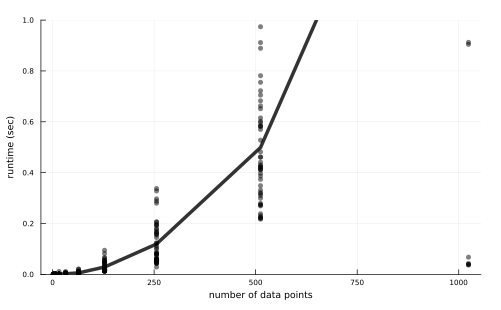

In [36]:
# with_theme(T) do
#     fig = Figure()
#     ax = Axis(fig[1, 1], xlabel = "number of data points", ylabel = "runtime (msec)")

#     sp = series!(ax, len_times, mean(times,dims=2)', ribbon=std(times,dims=2)')
#     # axislegend(ax)
#     # CairoMakie.ylims!(ax,-3,3)
#     hidespines!(ax, :t, :r)
#     save("figures/GPMat12_runtimes.pdf", fig, pt_per_unit = 1) # pt_per_unit is needed to ensure the correct sizes
# end

plot(xlabel="number of data points", ylabel="runtime (sec)")
# plot!(len_times, mean(times,dims=2), ribbon=std(times,dims=2)')
for (k,len_time) in enumerate(len_times)
    scatter!(len_time*ones(num_reps), times[k,:], color="black", alpha=0.5, label="")
end
plot!(len_times, mean(times,dims=2), linewidth=5, color="black", alpha=0.8, label="", ylims=(0,1.), margin=15Plots.pt)

In [38]:
savefig("figures/optGPMat12_runtimes.pdf")

"c:\\Syndr\\Wouter\\Onderzoek\\Projecten\\tue\\tgp-hopt-ar\\hopt-bar\\notebook\\figures\\optGPMat12_runtimes.pdf"